In [1]:
import pandas as pd

In [3]:
dataset=pd.read_csv("Preprocessed_data.csv")

In [4]:
dataset.isnull().sum()

sl_no             0
ssc_p             0
hsc_p             0
degree_p          0
etest_p           0
mba_p             0
salary            0
gender            0
ssc_b             0
hsc_b             0
hsc_s             0
degree_t          0
workex            0
specialisation    0
status            0
dtype: int64

In [6]:
import seaborn as sns

C:\Users\Default.DESKTOP-73FCCDO\AppData\Local\Temp\ipykernel_11416\2590864738.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset["ssc_p"])


<Axes: xlabel='ssc_p', ylabel='Density'>

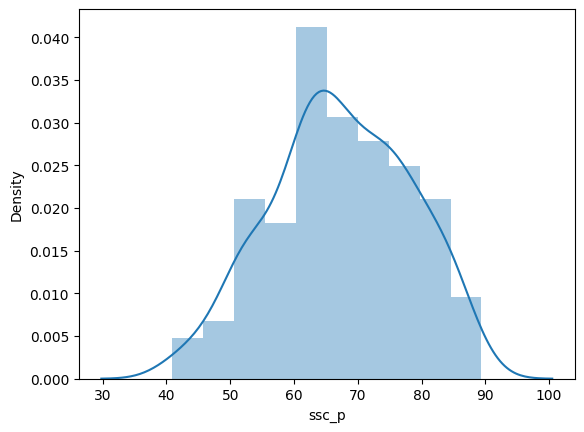

In [7]:
sns.distplot(dataset["ssc_p"])

# PDF

In [13]:
def get_pdf_probability(dataset,startrange,endrange):
    
    from matplotlib import pyplot   # library used to draw graphs
    from scipy.stats import norm    # library that provides the normal distribution formula
    import seaborn as sns           # library used to create statistical plots
    
    # draw a histogram and smooth curve to see how the data is distributed
    ax = sns.distplot(dataset,kde=True,kde_kws={'color':'blue'},color='Green')     # kde: kernel density function-for curve
     
     
    # draw red vertical lines to show where the range starts and ends
    pyplot.axvline(startrange,color='Red')   #ax v: vertical line
    pyplot.axvline(endrange,color='Red')
    
    # generate a sample
    sample = dataset   # store the dataset into a variable called sample
    
    # calculate parameters
    sample_mean =sample.mean()     # calculate the average value of the dataset
    sample_std = sample.std()     # calculate how spread out the data is (standard deviation)
    print('Mean=%.3f, Standard Deviation=%.3f' % (sample_mean, sample_std))   # print the mean and standard deviation rounded to 3 decimal places
    
    # define the distribution
    # create a normal distribution using the dataset's mean and standard deviation
    dist = norm(sample_mean, sample_std)  # norm: inbuilt function for normal distribution
    
    # sample probabilities for a range of outcomes
    # create a list of numbers between the start and end range
    values = [value for value in range(startrange, endrange)]   # in liner : one line for loop 

    # calculate the probability density for each value in that range
    probabilities = [dist.pdf(value) for value in values]  

    # add all the probabilities together to get the total probability
    prob=sum(probabilities)

    # print the probability (area under the curve) between the given range
    print("The area between range({},{}):{}".format(startrange,endrange,sum(probabilities)))
    
    return prob   # return the final probability value

Mean=67.303, Standard Deviation=10.827
The area between range(60,70):0.3449514151280293


C:\Users\Default.DESKTOP-73FCCDO\AppData\Local\Temp\ipykernel_11416\2452523331.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax = sns.distplot(dataset,kde=True,kde_kws={'color':'blue'},color='Green')     # kde: kernel density function-for curve


0.3449514151280293

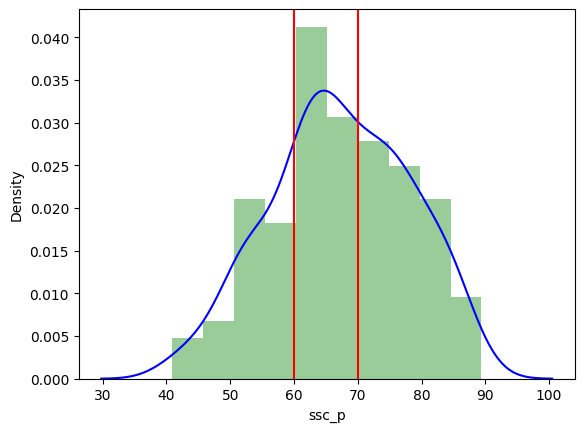

In [14]:
get_pdf_probability(dataset["ssc_p"],60, 70)

In [15]:
# def get_pdf_probability(dataset,startrange,endrange):
    from matplotlib import pyplot
    from scipy.stats import norm
    import seaborn as sns
    
    ax = sns.distplot(dataset,kde=True,kde_kws={'color':'blue'},color='Green')
    
    pyplot.axvline(startrange,color='Red')
    pyplot.axvline(endrange,color='Red')
    
    sample = dataset
    
    sample_mean = sample.mean()
    sample_std = sample.std()
    
    print('Mean=%.3f, Standard Deviation=%.3f' % (sample_mean, sample_std))
    
    dist = norm(sample_mean, sample_std)

    # Create an empty list and store every number between the start and end range into the list one by one
    values = []
    for value in range(startrange, endrange):
        values.append(value)

    # For each value in the list, calculate its probability using the PDF function and store those probabilities in another list.
    probabilities = []
    for value in values:
        prob = dist.pdf(value)
        probabilities.append(prob)
    
    total_probability = sum(probabilities)
    
    print("The area between range({},{}):{}".format(startrange,endrange,total_probability))
    
    return total_probability

C:\Users\Default.DESKTOP-73FCCDO\AppData\Local\Temp\ipykernel_11416\2142912700.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax = sns.distplot(dataset,kde=True,kde_kws={'color':'blue'},color='Green')


Mean=67.303, Standard Deviation=10.827
The area between range(60,70):0.3449514151280293


0.3449514151280293

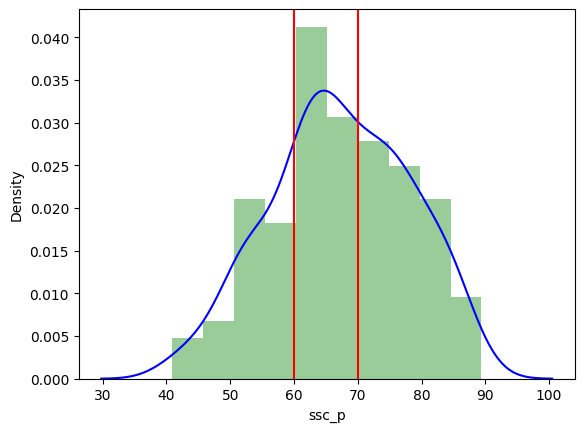

In [16]:
# get_pdf_probability(dataset["ssc_p"],60, 70)

## Instead of writing multiple lines with loops, we use list comprehension to write the same logic in one line for cleaner and easier code.
## It does the same work but makes the code shorter and easier to read.

#### values = [value for value in range(startrange, endrange)]
#### probabilities = [dist.pdf(value) for value in values]

# CDF

In [18]:
#!pip install statsmodels

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.5 MB 1.4 MB/s eta 0:00:07
   ---- ----------------------------------- 1.0/9.5 MB 1.5 MB/s eta 0:00:06
   ----- ---------------------------------- 1.3/9.5 MB 1.5 MB/s eta 0:00:06
   ------- -------------------------------- 1.8/9.5 MB 1.6 MB/s eta 0:00:05
   -------- ------------------------------- 2.1/9.5 MB 1.7 MB/s eta 0:00:05
   ---------- ----------------------------- 2.6/9.5 MB 1.7 MB/s eta 0:00:05
   ------------- -------------------------- 3.1/9.5 MB 1.8 MB/s eta 0:00:04
   -------------- ------------------------- 3.4/9.5 MB 1.8 MB/s eta 0:00:04
   -------------- ------------------------- 3.4/9.5 MB 1.8 MB/s eta 0:00:04
   --------------- ------------------------ 3.7/9.5 MB 1.5 MB/s eta 0:00:04
   --------------- --------------

In [19]:
from statsmodels.distributions.empirical_distribution import ECDF
ecdf = ECDF(dataset['ssc_p'])
ecdf(80)

0.8651162790697674

##### ECDF(80) gives the probability that SSC percentage is less than or equal to 80
##### Here 0.865 means about 86.5% of students scored ≤ 80 marks

# Standard Normal Distribution

In [20]:
def stdNBgraph(dataset):
       # converted to standard normal distribution
    import seaborn as sns   # Import seaborn library to create statistical graphs.
    mean=dataset.mean()     # Calculate the average value (mean) of the dataset.
    std=dataset.std()       # Calculate the standard deviation to know how spread the data is.

    values=[i for i in dataset]    # Create a list containing all the values from the dataset.
 
    z_score=[((j - mean) / std) for j in values]    # Convert each value into a Z-score using the formula (value − mean) / standard deviation.

    sns.distplot(z_score, kde=True)    # Plot the distribution of the Z-score values with a smooth density curve.

    sum(z_score)/len(z_score)   # Calculate the average of the Z-scores (it should be approximately 0).

C:\Users\Default.DESKTOP-73FCCDO\AppData\Local\Temp\ipykernel_11416\3135847529.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(z_score, kde=True)


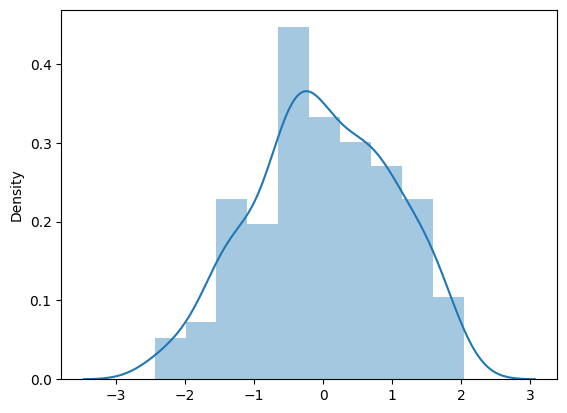

In [21]:
stdNBgraph(dataset["ssc_p"])